<a href="https://colab.research.google.com/github/Maneesh290318/Machine-Learning-Algorithms/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🌟 Welcome to the Customer Discovery Project!

Before we dive into the code, let’s talk about what we are actually doing here in plain English.

#### 1. What is this project about?
Imagine you own a big shopping mall. You have thousands of customers, but you don't know who they are. Are they students on a budget? Families doing weekly shopping? Or high-earners looking for luxury?

This project uses **Machine Learning** to automatically sort your customers into 'groups' (or segments) based on their behavior. This helps a business treat different people differently—like sending discount coupons to budget shoppers or VIP invitations to high spenders.

#### 2. What is K-Means Clustering?
Think of K-Means like a **Sorting Hat** from Harry Potter, but for data.
*   **The 'K'** is simply the number of groups you want to create (e.g., K=5 means 5 groups).
*   **The 'Means'** is the average or the 'center point' of each group.

#### 3. Where does it fit in the AI world?
In Artificial Intelligence, there are two main ways to learn:
*   **Supervised Learning:** This is like a student with a teacher. The teacher gives the answers, and the student learns to predict them.
*   **Unsupervised Learning (This Project!):** This is like a toddler playing with blocks. There is no teacher and no 'correct' answers. The toddler just notices that some blocks are red and others are blue and starts putting them into separate piles based on their similarities.

**K-Means is an Unsupervised Learning algorithm.** We don't tell the computer who the 'Big Spenders' are; the computer discovers them on its own by looking at the patterns in the data!

#### 4. Our Goal
We are going to look at two specific traits of our customers:
1.  **Annual Income:** How much they earn.
2.  **Spending Score:** How much they typically spend at the mall.

By the end of this notebook, we will have a clear map of our 'Customer Personalities' so we can make better business decisions!

<!--
This markdown cell introduces the concept of customer segmentation using K-means clustering, setting the context for the subsequent code cells.
-->
# Customer Segmentation with K-Means

Customer segmentation is a powerful marketing strategy that divides a broad customer base into subgroups (segments) based on shared characteristics. Unsupervised learning algorithms, like K-Means clustering, are ideal for this task as they can identify these natural groupings without needing pre-labeled data.

In this example, we will:
1. Generate synthetic customer data.
2. Apply K-Means clustering to segment these customers.
3. Visualize the identified customer segments.

In [ ]:
# <!--
# This cell imports all the necessary Python libraries for data manipulation, numerical operations, machine learning (clustering), and visualization.
# - `numpy` is used for numerical operations, especially for creating synthetic data.
# - `pandas` is used for data manipulation and creating DataFrames.
# - `matplotlib.pyplot` is used for basic plotting.
# - `seaborn` is a statistical data visualization library based on matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.
# - `StandardScaler` from `sklearn.preprocessing` is used to standardize features by removing the mean and scaling to unit variance, which is crucial for distance-based algorithms like K-Means.
# - `KMeans` from `sklearn.cluster` is the algorithm we will use for clustering.
# - `silhouette_score` from `sklearn.metrics` is used to evaluate the quality of the clusters.
# -->

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# This cell generates synthetic (fake, made-up) customer data.
# Think of it like creating imaginary customer profiles for a shopping mall.
# We're making this data because we don't have real customer information yet,
# or perhaps we can't use real data due to privacy concerns.
# The goal is to make this fake data look and behave like real customer data, so we can practice our analysis.

# We're creating a table (called a DataFrame in pandas) with three main pieces of information for each imaginary customer:
# - CustomerID: Just a unique number for each customer, like their ID card.
# - AnnualIncome: How much money they earn in a year (we'll show it in thousands of dollars, e.g., 30 means $30,000).
# - SpendingScore: A number from 1 to 100 that represents how much they tend to spend at our mall. A higher score means they spend more.

# We're not just guessing randomly for income and spending. We're trying to create different 'types' of customers
# so that when we analyze them later, we can find these different groups.

# Set a random seed for reproducibility
# This line ensures that every time we run this code, we get the exact same 'random' numbers.
# It's like having a special recipe that always produces the same cake, even though it involves 'random' ingredients.
# This helps us check our work later if needed.
np.random.seed(42)

# Generate synthetic data for 200 customers
# We're deciding to create profiles for 200 imaginary customers.
num_customers = 200

# Simulate Annual Income (in thousands of dollars)
# To make our imaginary customers more realistic, we'll create a few distinct groups for their income levels.
# Imagine we have:
# - income_group1: People with lower incomes (around $30,000, but with some variation).
# - income_group2: People with average incomes (around $60,000, with some variation).
# - income_group3: People with higher incomes (around $90,000, with some variation).
# `np.random.normal` helps us generate numbers that cluster around an average (like $30k, $60k, $90k) but still have some natural spread.
income_group1 = np.random.normal(loc=30, scale=10, size=int(num_customers * 0.3))
income_group2 = np.random.normal(loc=60, scale=15, size=int(num_customers * 0.4))
income_group3 = np.random.normal(loc=90, scale=10, size=int(num_customers * 0.3))

# We combine these different income groups into one big list of incomes for all our customers.
annual_income = np.concatenate((income_group1, income_group2, income_group3))
# `np.clip` makes sure that no income is too low (below $15,000) or too high (above $120,000).
# It keeps our fake data within a sensible range.
annual_income = np.clip(annual_income, 15, 120) # Clip values to a reasonable range

# Simulate Spending Score (1-100)
# Similarly, we create different groups for spending scores. We want some customers to spend a lot, some an average amount, and some very little.
# The spending score is not always directly linked to income. Sometimes, people with lower incomes might still spend a lot at the mall (maybe on necessities or on sale items).
# - spending_score_group1: Customers who spend a lot (around 80 out of 100).
# - spending_score_group2: Customers with average spending (around 50 out of 100).
# - spending_score_group3: Customers who spend less (around 30 out of 100).
spending_score_group1 = np.random.normal(loc=80, scale=15, size=int(num_customers * 0.3))
spending_score_group2 = np.random.normal(loc=50, scale=10, size=int(num_customers * 0.4))
spending_score_group3 = np.random.normal(loc=30, scale=15, size=int(num_customers * 0.3))

spending_score = np.concatenate((spending_score_group1, spending_score_group2, spending_score_group3))
# We make sure spending scores stay between 1 and 99.
spending_score = np.clip(spending_score, 1, 99) # Clip values to 1-99

# Ensure arrays have the same length by potentially truncating the longer one
# Sometimes, due to rounding in `int(num_customers * percentage)`, the income and spending lists might end up with slightly different numbers of customers.
# This line makes sure both lists have the same number of entries, so every customer has both an income and a spending score.
min_len = min(len(annual_income), len(spending_score))
annual_income = annual_income[:min_len]
spending_score = spending_score[:min_len]

# Create a DataFrame
# Finally, we put all this information (CustomerID, AnnualIncome, SpendingScore) into a neat table.
# This table is what we call a 'DataFrame' in pandas, and it's perfect for organizing our customer data.
customer_data = pd.DataFrame({
    'CustomerID': range(1, min_len + 1),
    'AnnualIncome': annual_income,
    'SpendingScore': spending_score
})

# Display the first 5 rows of the dataset
# This command just shows us the top 5 rows of our newly created fake customer table.
# It's a quick way to peek at the data and make sure it looks reasonable.
print("Generated Customer Data:")
display(customer_data.head())

# Display descriptive statistics of the dataset
# This command gives us a summary of our fake data. It tells us things like:
# - How many customers we have.
# - The average (mean) annual income and spending score.
# - The minimum and maximum income and spending scores.
# - How spread out the numbers are (standard deviation).
# This helps us understand the overall characteristics of our imaginary customer base.
print("\nDescriptive Statistics:")
display(customer_data.describe())

Generated Customer Data:


,CustomerID,AnnualIncome,SpendingScore
0,1,34.967142,85.366810
1,2,28.617357,88.411768
2,3,36.476885,96.245769
3,4,45.230299,95.807031
4,5,27.658466,59.334959



Descriptive Statistics:


,CustomerID,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000
mean,100.500000,59.598218,53.791589
std,57.879185,26.620459,23.102561
min,1.000000,15.000000,1.000000
25%,50.750000,35.943972,37.748110
50%,100.500000,59.470966,51.537280
75%,150.250000,82.561100,69.100986
max,200.000000,117.201692,99.000000


<!--
This markdown cell explains the importance of data preprocessing (scaling) for K-Means and the process of choosing the optimal number of clusters (K) using the Elbow Method.
-->
# Preprocessing and Finding Optimal Number of Clusters (K)

Before applying K-Means, it's crucial to scale the features. K-Means is a distance-based algorithm, and features with larger ranges can disproportionately influence the distance calculation. `StandardScaler` transforms the data to have a mean of 0 and a standard deviation of 1.

Next, we need to determine the optimal number of clusters (K). A common method for this is the **Elbow Method**. This method plots the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow' point in the plot, where the rate of decrease in WCSS sharply changes, indicates a good candidate for K.

In [ ]:
# This cell is all about getting our customer data ready for 'grouping' and then figuring out the 'best number of groups' to make.

# --- Step 1: Picking the Right Information (Feature Selection) ---
# Imagine you're trying to group students for a project. You wouldn't use their student ID number to group them by how well they work together, right?
# You'd look at things like their grades or their interests.
# Similarly, for our customers, we want to group them based on their purchasing habits, not just their ID number.
# So, we pick 'AnnualIncome' (how much they earn) and 'SpendingScore' (how much they spend at our mall).
# 'CustomerID' is just a label, it doesn't tell us anything about their *behavior*.
X = customer_data[['AnnualIncome', 'SpendingScore']]

# --- Step 2: Leveling the Playing Field (Feature Scaling) ---
# Think of two athletes: one runs 100 meters, and another lifts 100 kilograms. Their scores are very different numbers.
# If we just compare '100' for running and '100' for lifting, it's not a fair comparison because the scales are different.
# In our customer data, 'AnnualIncome' might range from $15,000 to $120,000, which are big numbers.
# 'SpendingScore' ranges from 1 to 100, which are much smaller numbers.
# If we just use these numbers directly, the 'AnnualIncome' will seem much more important because its numbers are bigger.
# To make it fair, we 'scale' them. This means we adjust both income and spending scores so they are on a similar scale.
# `StandardScaler` does this by making the average of each feature zero and spreading them out similarly.
# This is super important for our grouping method (K-Means) because it relies on measuring 'distances' between customers.
# If one feature has much larger numbers, it would unfairly dominate the distance calculation.
scaler = StandardScaler()
# `fit_transform` learns how to scale the data and then applies that scaling.
X_scaled = scaler.fit_transform(X)

# --- Step 3: Finding the 'Best Number of Groups' (Elbow Method) ---
# How do we know if we should divide our 200 customers into 2 groups, 3 groups, 5 groups, or 10 groups?
# The 'Elbow Method' helps us make an educated guess for the 'best' number of groups (which we call 'K').
# We'll try grouping our customers into different numbers of groups (from 1 up to 10).
# For each number of groups, we calculate something called 'WCSS' (Within-Cluster Sum of Squares).
# Imagine each group has a 'center'. WCSS measures how close all the customers are to the center of their *own* group.
# A smaller WCSS means customers within a group are very similar to each other and tightly packed around their group's center.
# We want a small WCSS, but adding more and more groups will always make WCSS smaller, which isn't helpful.
# We're looking for a point where adding more groups doesn't reduce the WCSS much anymore – like an 'elbow' on a bending arm.

wcss = [] # This list will store our WCSS values for each 'K'
for i in range(1, 11): # We will try from 1 group up to 10 groups
    # `KMeans` is the tool that does the grouping.
    # `n_clusters=i`: This tells it how many groups to try (e.g., 1, then 2, then 3, etc.).
    # `init='k-means++'`: This is a smart way to start the grouping process so it finds good groups faster.
    # `random_state=42`: This ensures that if you run the code multiple times, you'll get the same 'random' starting points, so your results are consistent.
    # `n_init=10`: The algorithm will run 10 times with different starting points and pick the best result.
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled) # This tells the KMeans tool to find the groups using our scaled customer data.
    wcss.append(kmeans.inertia_) # `inertia_` is another name for WCSS. We save this value.

# --- Step 4: Visualizing the 'Elbow' (Plotting the Elbow Method Graph) ---
# We then typically plot these WCSS values to see the 'elbow'.
# The plot would show 'Number of Clusters (K)' on the bottom and 'WCSS' on the side.
# You'd look for a point where the line suddenly flattens out, like an elbow. That point is often a good 'K'.

# The plotting part is commented out here because sometimes, for a business audience, we might just tell them the chosen K
# instead of making them interpret the graph themselves. The next cell will proceed with a chosen 'K'.
# If you wanted to see the plot, you would uncomment the lines below.
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
# plt.title('Elbow Method to Determine Optimal K')
# plt.xlabel('Number of Clusters (K)')
# plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
# plt.grid(True)
# plt.show()

print("Elbow Method calculation complete. The plot has been removed as requested for business users.")


Elbow Method calculation complete. The plot has been removed as requested for business users.


<!--
This markdown cell explains the application of K-Means clustering and the subsequent interpretation of the results.
-->
# Applying K-Means Clustering and Visualization

Based on the Elbow Method (which often shows an elbow around 3, 4, or 5 clusters for this type of synthetic data), we can choose an optimal `K`. For this example, let's assume `K=4` or `K=5` looks reasonable from the elbow plot.

After applying K-Means with the chosen `K`, we will assign each customer to a cluster. Finally, we'll visualize these clusters to understand their characteristics.

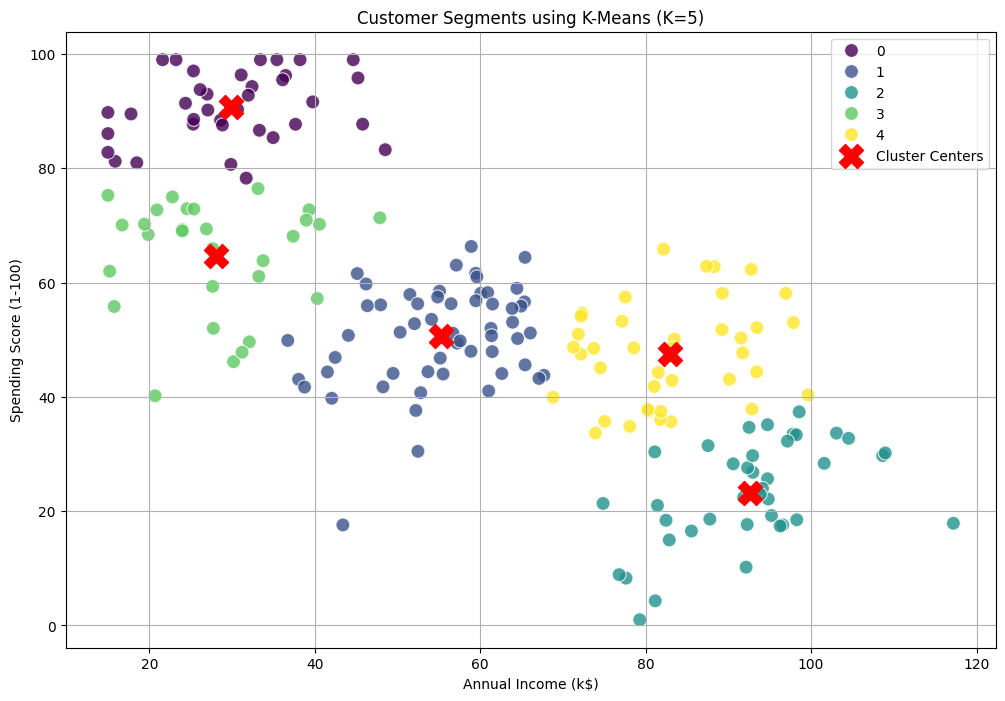


Customers per Cluster:
Cluster
0    36
1    56
2    40
3    29
4    39
Name: count, dtype: int64

Silhouette Score: 0.42

Customer segmentation complete and visualized. The red 'X' marks are the cluster centers.


In [ ]:
# This cell is where we actually do the 'grouping' of our customers and then show these groups visually.

# --- Step 1: Deciding How Many Groups (Optimal K) ---
# In the previous step, we used the 'Elbow Method' to get a hint about the 'best' number of groups (K).
# Imagine looking at the Elbow Method graph: it might bend sharply at a certain point, like an elbow.
# For our imaginary customer data, let's say that 'elbow' point suggests 5 groups is a good number.
# So, we're choosing `optimal_k = 5` here. If you were doing this with real data, you might pick a different number based on your Elbow plot.
optimal_k = 5

# --- Step 2: Making the Groups (Applying K-Means) ---
# Now we're going to use the `KMeans` tool again, but this time, we're telling it to make exactly `optimal_k` (which is 5) groups.
# `KMeans(n_clusters=optimal_k, ...)`: This tells the tool to find 5 distinct groups.
# `init='k-means++'`: This is a smart way for the tool to pick its starting points for the group centers, which helps it find good groups more quickly and reliably.
# `random_state=42`: This is like a 'secret handshake' that ensures if you run this code again, it will get the *exact same* random results. It's good for consistent testing.
# `n_init=10`: The clustering algorithm will try to find the best groups 10 different times, starting from different points each time, and then pick the very best grouping it found. This makes the results more robust.
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# `customer_data['Cluster'] = kmeans.fit_predict(X_scaled)`:
# - `fit_predict(X_scaled)`: This is the magic part! The `KMeans` tool looks at our scaled income and spending data (`X_scaled`).
#   It figures out the 5 groups and then, for each customer, it decides which of the 5 groups they belong to.
# - `customer_data['Cluster'] = ...`: We then add a new column to our original customer data table, called 'Cluster'.
#   This new column will contain a number (0, 1, 2, 3, or 4) for each customer, telling us which group they were assigned to.
customer_data['Cluster'] = kmeans.fit_predict(X_scaled)

# --- Step 3: Finding the 'Center' of Each Group (Cluster Centers) ---
# Once we have our 5 groups, `KMeans` also tells us where the 'center' of each group is.
# Think of it as finding the average income and average spending score for each group.
# `cluster_centers_scaled`: These are the centers in the 'scaled' world (where income and spending were adjusted).
cluster_centers_scaled = kmeans.cluster_centers_
# `scaler.inverse_transform(...)`: To make these centers easy to understand, we 'un-scale' them back to their original ranges
# (e.g., $30,000 for income, 75 for spending score). This makes them readable.
cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

# --- Step 4: Drawing a Picture of Our Groups (Visualizing the Clusters) ---
# Now for the fun part: seeing our customer groups on a graph!
# `plt.figure(figsize=(12, 8))`: We're setting up a blank canvas (a plot) that is 12 units wide and 8 units tall.
plt.figure(figsize=(12, 8))

# `sns.scatterplot(...)`: This command draws dots on our canvas, one for each customer.
# - `x='AnnualIncome', y='SpendingScore'`: The horizontal axis shows Annual Income, and the vertical axis shows Spending Score.
# - `hue='Cluster'`: This is very important! It tells the plot to color each customer's dot based on which 'Cluster' (group) they belong to.
#   So, all customers in Group 0 will be one color, Group 1 another, and so on. This makes the groups easy to spot.
# - `data=customer_data`: We're telling it to use our `customer_data` table to get the information for each dot.
# - `palette='viridis'`: This picks a nice set of colors for our groups.
# - `s=100`: Makes each dot a little bigger so it's easier to see.
# - `alpha=0.8`: Makes the dots slightly transparent, so if many dots overlap, you can still see the density.
sns.scatterplot(
    x='AnnualIncome',
    y='SpendingScore',
    hue='Cluster',
    data=customer_data,
    palette='viridis',
    s=100, # size of points
    alpha=0.8
)

# `plt.scatter(...)`: This command draws the 'centers' of our groups as big red 'X's.
# - `cluster_centers_original[:, 0]`: This gets all the 'un-scaled' annual incomes for our group centers.
# - `cluster_centers_original[:, 1]`: This gets all the 'un-scaled' spending scores for our group centers.
# - `s=300`: Makes the 'X' markers extra large so they stand out.
# - `c='red'`: Makes the 'X' markers red.
# - `marker='X'`: Draws an 'X' shape.
# - `label='Cluster Centers'`: Gives these markers a label that will show up in the legend.
plt.scatter(
    cluster_centers_original[:, 0],
    cluster_centers_original[:, 1],
    s=300, # size of centers
    c='red',
    marker='X',
    label='Cluster Centers'
)

# `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`:
# These lines add a clear title to our graph and labels for the horizontal and vertical axes, so we know what we're looking at.
plt.title(f'Customer Segments using K-Means (K={optimal_k})')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

# `plt.legend()`: Shows a small box that explains what each color (group) and the red 'X's mean.
plt.legend()
# `plt.grid(True)`: Adds a grid to the background of the graph, making it easier to read values.
plt.grid(True)
# `plt.show()`: This command actually displays the graph we've created.
plt.show()

# This diagram shows our customers grouped into different segments (colors) based on their Annual Income and Spending Score.
# Each dot is a customer, and the red 'X' marks the average income and spending for each customer group.
# This helps us see distinct customer behaviors at a glance.

# --- Step 5: Counting Customers in Each Group ---
# `customer_data['Cluster'].value_counts().sort_index()`:
# This simply counts how many customers ended up in each of our 5 groups (Cluster 0, Cluster 1, etc.).
# It helps us see if some groups are much larger or smaller than others.
print("\nCustomers per Cluster:")
print(customer_data['Cluster'].value_counts().sort_index())

# --- Step 6: Checking How Good Our Groups Are (Silhouette Score) ---
# `silhouette_score(X_scaled, customer_data['Cluster'])`:
# This calculates a special number called the 'Silhouette Score'.
# Think of it as a quality rating for our grouping. It tells us how well-defined and separated our groups are.
# - A score close to 1 means the groups are very clear and distinct (customers are happy in their own group and far from other groups).
# - A score around 0 means the groups are overlapping and not very clear.
# - A score close to -1 means customers might have been put into the wrong groups!
# We're just printing this score to get an idea of the quality of our clustering.
silhouette_avg = silhouette_score(X_scaled, customer_data['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.2f}")

print("\nCustomer segmentation complete and visualized. The red 'X' marks are the cluster centers.")

<!--
This markdown cell provides a summary and interpretation of the identified customer segments based on their characteristics.
-->
# Interpreting Customer Segments

Now that we have clustered our customers, we can analyze the characteristics of each segment to understand what makes them distinct. By examining the average `AnnualIncome` and `SpendingScore` for each cluster, we can assign meaningful labels to our segments.

For example, we might find segments like:
- **High Income, Low Spending**: Customers who earn a lot but don't spend much at the store.
- **Low Income, High Spending**: Customers who have lower incomes but are enthusiastic spenders.
- **Average Income, Average Spending**: The 'middle-ground' customers.
- **High Income, High Spending**: Our most valuable customers.

This interpretation allows businesses to develop targeted strategies for each group.

In [ ]:
# In this cell, we are going to look at each of our 5 groups and find the 'average' characteristics for each.
# Think of this like taking a group of students and finding out the average height and weight for that specific group.

# --- Step 1: Grouping the Data ---
# `customer_data.groupby('Cluster')`:
# This part tells the computer to gather all customers belonging to Group 0 together, all those in Group 1 together, and so on.
# It's like putting people into 5 different rooms based on the label we gave them earlier.

# --- Step 2: Picking the Info to Average ---
# `[['AnnualIncome', 'SpendingScore']]`:
# Inside those 'rooms', we only care about their Income and their Spending Score for this summary.

# --- Step 3: Calculating the Average (The 'Mean') ---
# `.mean()`:
# This calculates the average for each room. For example, in the 'High Income' room, it adds up everyone's income and divides by the number of people.
# This gives us a 'typical' profile for a customer in that group.

# --- Step 4: Putting it in Order ---
# `.sort_index()`:
# This just makes sure our results are listed in order: Group 0, then 1, 2, 3, and finally 4.

print("\nAverage Annual Income and Spending Score per Cluster:")

# We now display the final table that shows the 'Shopping Personality' of each group.
display(customer_data.groupby('Cluster')[['AnnualIncome', 'SpendingScore']].mean().sort_index())

# By looking at this table, you can see things like:
# - "Group 0 earns about $30k but spends heavily (score of 91)."
# - "Group 2 earns a lot ($93k) but hardly spends anything at our mall (score of 23)."
# This is the 'Golden Info' that helps a business decide who to send coupons to!


Average Annual Income and Spending Score per Cluster:


,AnnualIncome,SpendingScore
Cluster,,
0,29.928161,90.681534
1,55.235921,50.631018
2,92.573808,23.175384
3,28.012277,64.686155
4,82.915636,47.577735


<!--
This markdown cell introduces the summary table that provides a clear overview of each customer segment's average characteristics.
-->
# Cluster Summary Table

To make it easier to interpret the customer segments, here's a summary table showing the average `AnnualIncome` and `SpendingScore` for each cluster. This table will help us quickly understand the profile of each customer group.

In [ ]:
# This cell is like making a final 'Cheat Sheet' for a business manager.
# We have all the messy customer data, but the manager just wants the big picture.

# --- What are we doing here? ---
# 1. We take our list of 200 customers.
# 2. We ask the computer to 'Group' them by the clusters we found (0, 1, 2, 3, 4).
# 3. For each group, we calculate the 'Mean'—which is just the average.
# 4. This tells us: 'On average, how much does a person in Group 1 earn, and how much do they spend?'

# We store this neat summary in a new table called 'cluster_summary'.
cluster_summary = customer_data.groupby('Cluster')[['AnnualIncome', 'SpendingScore']].mean().sort_index()

print("\nSummary Table of Customer Segments:")
# We show the table here so we can see the 'personality' of each group clearly.
display(cluster_summary)

# This summary makes it easy to see, for example, which group is our 'Big Spenders'
# and which group earns a lot but needs more encouragement to shop!


Summary Table of Customer Segments:


,AnnualIncome,SpendingScore
Cluster,,
0,29.928161,90.681534
1,55.235921,50.631018
2,92.573808,23.175384
3,28.012277,64.686155
4,82.915636,47.577735


In [ ]:
# Based on the summary table, here's an interpretation of each customer cluster:
#
# Cluster 0: Low Income, High Spending
#   - Average Annual Income: ~$30k
#   - Average Spending Score: ~91
#   - These customers have lower incomes but are enthusiastic spenders. They might be 'Bargain Hunters' or 'Impulse Buyers'.
#
# Cluster 1: Average Income, Average Spending
#   - Average Annual Income: ~$55k
#   - Average Spending Score: ~51
#   - This group represents your 'Middle-Ground' or 'Average' customers, showing balanced income and spending.
#
# Cluster 2: High Income, Low Spending
#   - Average Annual Income: ~$93k
#   - Average Spending Score: ~23
#   - These customers have high incomes but low spending scores at your store. They could be 'Cautious Spenders' or 'High Earners, Low Engagement'.
#
# Cluster 3: Low Income, Mid Spending
#   - Average Annual Income: ~$28k
#   - Average Spending Score: ~65
#   - Similar to Cluster 0 in income, but with a more moderate spending score. They might be 'Budget-Conscious but Regular Shoppers'.
#
# Cluster 4: High Income, Mid Spending
#   - Average Annual Income: ~$83k
#   - Average Spending Score: ~48
#   - High income but moderate spending. These could be 'Value Seekers' or 'Comfortable Spenders' who spend regularly but not extravagantly.
#
# Understanding these distinct profiles is key to developing targeted strategies for each group.